# 18j — Corridors-out isolation test (PF-4, study plan v0.18.1): the comparison and the register's reading rule

Reads the registered balanced anchor (`runs_v3.1/s0_ssp585_theta5/anchor.tif`) and the corridors-out anchor solved by 18i
(`runs_v3.1/pf4_corridors_out/s0_ssp585_theta5/anchor.tif`), with the arm written by 18h. Reports: Jaccard on discretionary
selections (locked protected areas excluded), what the swap is made of (driver masks, multi-claim land, frozen-core membership),
per-value capture shifts for the eight continuous values plus the EFG block (block-mean capture, capture ÷ target, targets met of 20)
under both anchors and under the locked protected areas alone, corridor capture as a co-benefit under the new anchor (share of the
registered discretionary corridor capture retained at weight 0), and the register's **reading rule** — "Jaccard near 1 → corridors is
a decoration and Decision 1 = B; Jaccard noticeably below → corridors was shaping the balanced map and B is a real change to be
stated as such" — with "near 1" operationalized at 0.95 (disclosed in the rule cell, not in the register). Zero solves.
Products: `spec/v3.1/PF4_corridors_out_captures.csv`, `PF4_corridors_out_efg_captures.csv`, `PF4_corridors_out_swap_composition.csv`,
`PF4_corridors_out_summary.json`, `figures/v3.1/pf4_corridors_out_swap.png`.


In [1]:
# ---- bootstrap: the arm (18h) and the two anchors (registered; 18i) ------------------------------------------------------------
import importlib, json, pathlib, sys
import numpy as np
import pandas as pd
import rasterio
import matplotlib.pyplot as plt
_cands = [p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents] if (p / "config.py").exists()]
ROOT = _cands[0]; sys.path.insert(0, str(ROOT))
import config, leverage_core as lc, ensemble_core as ec, director_core as dc
for _m in (config, lc, ec, dc):
    importlib.reload(_m)
VP = dc.VP; assert VP.version == "v3.1", "PF-4 is a post-freeze sensitivity on the v3.1 record"
G = dc.grid(); RUNS, REC, PKG = dc.RUNS, dc.SPEC_REC, dc.PKG
FIG = ROOT / "analyses" / "y2y" / "figures" / VP.version; FIG.mkdir(exist_ok=True, parents=True)
payload = json.loads((REC / "pf4_corridors_out.json").read_text())                     # written by 18h
FID, ARM = payload["base_formulation"], payload["arm"]
w_pf4, w_reg, t_full = payload["weights"], payload["weights_registered"], payload["targets"]
ANCH = ROOT / payload["out_rel"] / FID / "anchor.tif"
assert ANCH.exists(), "the corridors-out anchor is not on disk: run 18i first"
a_reg = ec.read_selections(RUNS / FID / "anchor.tif", G.pu)[0]; a_new = ec.read_selections(ANCH, G.pu)[0]
meta_reg = json.loads((RUNS / FID / "formulation_meta.json").read_text()); meta_new = json.loads((ANCH.parent / "formulation_meta.json").read_text())
assert all(abs(float(meta_new["weights"][f]) - w_pf4[f]) < 1e-6 for f in w_pf4), "18i solved a different arm than 18h wrote"
assert a_reg[G.locked].all() and a_new[G.locked].all(), "locked protected areas must be selected in both anchors"
assert abs(int(a_new.sum()) - int(a_reg.sum())) <= 1, f"budgets differ: {int(a_reg.sum()):,} vs {int(a_new.sum()):,}"
print(f"{ARM}: {payload['label']}\nregistered S0 anchor z {meta_reg['anchor_objective']:.4f} | PF-4 anchor z {meta_new['anchor_objective']:.4f} "
      f"(a different objective: not comparable in level; gap {meta_new['anchor_gap']:.1e}, {meta_new['anchor_runtime_s']:.0f} s) | "
      f"transboundary weight {w_reg['transboundary_connectivity']:.4f} -> {w_pf4['transboundary_connectivity']:.4f}, corridors {w_reg['climate_corridors']:.4f} -> {w_pf4['climate_corridors']:.1f}")


pf4_corridors_out: PF-4: corridors out -- climate corridors removed from the objective, transboundary connectivity alone on the connectivity block's 25%
registered S0 anchor z 4.9025 | PF-4 anchor z 4.1826 (a different objective: not comparable in level; gap 2.0e-06, 39 s) | transboundary weight 0.6693 -> 1.2361, corridors 1.1714 -> 0.0


In [2]:
# ---- Jaccard on discretionary selections and what the swap is made of -----------------------------------------------------
D = G.disc; both = a_reg & a_new & D; either = (a_reg | a_new) & D
J = float(both.sum() / either.sum()); dropped = a_reg & ~a_new & D; gained = a_new & ~a_reg & D
print(f"Jaccard on discretionary selections {J:.4f} | dropped {int(dropped.sum()):,} km2 | gained {int(gained.sum()):,} km2 "
      f"({100 * dropped.sum() / (a_reg & D).sum():.1f}% of the registered discretionary selection swapped)")
DM = dc.driver_masks(G)
with rasterio.open(PKG / "geotiffs" / "value_convergence.tif") as s:
    conv = s.read(1)[G.pu]
with rasterio.open(PKG / "geotiffs" / "act_tiers_guarded.tif") as s:
    core = (s.read(1)[G.pu] == 3)
units = [("registered discretionary selection", a_reg & D), ("PF-4 discretionary selection", a_new & D), ("kept by both", both),
         ("dropped under PF-4", dropped), ("gained under PF-4", gained)]
COMP = pd.DataFrame({nm: dict(km2=int(m.sum()), **{k: (100 * float(v[m].mean()) if m.any() else np.nan) for k, v in DM.items()},
                              **{"multi-claim (>=2 themes top-30%)": (100 * float((conv[m] >= 2).mean()) if m.any() else np.nan),
                                 "inside the frozen core": (100 * float(core[m].mean()) if m.any() else np.nan)}) for nm, m in units}).T
COMP.to_csv(REC / "PF4_corridors_out_swap_composition.csv")
pd.set_option("display.width", 240); print(COMP.round(1).to_string())
print(f"core cells in the registered anchor {int((core & a_reg).sum()):,} -> in the PF-4 anchor {int((core & a_new).sum()):,} (of {int(core.sum()):,})")


Jaccard on discretionary selections 0.6857 | dropped 35,578 km2 | gained 35,578 km2 (18.6% of the registered discretionary selection swapped)
driver masks: m_soc theta-tail 51,698 cells | refugia densest (same area) | spike 2,546 | rare-attainable EFG footprint 886,424 cells (70% of PU) from 17/20 EFGs | rarest-EFG footprint 7,504 cells (0.6%) from 2 EFGs
                                         km2  m_soc theta-tail  connectivity spike (top 0.2%)  refugia densest (area-matched to the m_soc tail)  rare-attainable EFG footprint  rarest-EFG footprint (rare in the extent+250 km window: <= 1% of the window)  multi-claim (>=2 themes top-30%)  inside the frozen core
registered discretionary selection  190845.0               5.0                            1.0                                              18.1                           69.0                                                                           1.2                              75.3                    15.2
PF-4 discretionary s

In [3]:
# ---- per-value captures: the eight continuous values + the EFG block, under both anchors and the locked protected areas alone ------
cont = lc.continuous_features()
SELS = {"registered": a_reg, "pf4": a_new, "locked_only": G.locked}
rows = {}
for feat in cont:
    v = lc._read(config.HANDOFF_DIR / f"{feat}.tif"); vp = np.nan_to_num(v[G.pu], nan=0.0); tot = vp.sum()
    rows[feat] = {k: float(vp[s].sum() / tot) for k, s in SELS.items()}
efg = {}
for p in lc.efg_paths():
    v = lc._read(p); vp = np.nan_to_num(v[G.pu], nan=0.0); tot = vp.sum(); t = float(t_full[p.stem])
    efg[p.stem] = dict({k: float(vp[s].sum() / tot) for k, s in SELS.items()}, target=t)
EFG = pd.DataFrame(efg).T
for k in SELS: EFG[f"{k}_met"] = EFG[k] >= EFG["target"] - 1e-9
rows["EFG block (mean of 20 captures)"] = {k: float(EFG[k].mean()) for k in SELS}
rows["EFG block (mean capture / target, capped at 1)"] = {k: float(np.minimum(EFG[k] / EFG["target"], 1.0).mean()) for k in SELS}
rows["EFG targets met (of 20)"] = {k: int(EFG[f"{k}_met"].sum()) for k in SELS}
CAP = pd.DataFrame(rows).T; CAP["delta_pf4_minus_registered_pts"] = 100 * (CAP["pf4"] - CAP["registered"])
CAP.loc["EFG targets met (of 20)", "delta_pf4_minus_registered_pts"] = CAP.loc["EFG targets met (of 20)", "pf4"] - CAP.loc["EFG targets met (of 20)", "registered"]
CAP.to_csv(REC / "PF4_corridors_out_captures.csv"); EFG.to_csv(REC / "PF4_corridors_out_efg_captures.csv")
print("captured fraction of the PU total (locked protected areas contribute to every selection):")
print(CAP.to_string(float_format=lambda x: f"{x:.4f}"))
c_reg, c_new, c_lock = (rows["climate_corridors"][k] for k in ("registered", "pf4", "locked_only"))
retained = (c_new - c_lock) / (c_reg - c_lock)
print(f"\nCORRIDOR CO-BENEFIT under the corridors-out anchor: capture {c_new:.4f} vs {c_reg:.4f} registered (weight 1.171) and {c_lock:.4f} from the locked "
      f"protected areas alone; budget line 0.30; the discretionary part of the registered corridor capture retained: {100 * retained:.1f}%")


captured fraction of the PU total (locked protected areas contribute to every selection):
                                                registered     pf4  locked_only  delta_pf4_minus_registered_pts
human_modification                                  0.3059  0.3053       0.1550                         -0.0568
transboundary_connectivity                          0.3542  0.3861       0.1493                          3.1905
climate_corridors                                   0.2812  0.2669       0.1428                         -1.4267
climate_type_macrorefugia                           0.4742  0.4540       0.1917                         -2.0229
irrecoverable_carbon_biomass                        0.3718  0.3438       0.1226                         -2.8000
irrecoverable_carbon_m_soc                          0.3320  0.3320       0.1764                         -0.0009
aoh_richness_mammals                                0.3260  0.3306       0.1591                          0.4572
aoh_richness_b

In [4]:
# ---- the register's reading rule (study plan v0.18.1, PF-4) + the summary record ------------------------------------------
# Rule (verbatim): "Jaccard near 1 -> corridors is a decoration and Decision 1 = B ('removing a layer that was not shaping the map');
# Jaccard noticeably below -> corridors was shaping the balanced map and B is a real change to be stated as such."
# The rule is qualitative; the operationalization is DISCLOSED here, not written into the register: "near 1" = at or above the level a
# pure shape change on this same formulation reached (PF-1 saturating-refugia anchor vs registered: Jaccard 0.957, read as "the core is
# robust"; the LP-vs-MILP numerical near-tie sits at 0.9957) -> NEAR_ONE = 0.95. Below that, the value is read against the record's
# scale of real value changes (between-scenario anchors 0.373-0.931 in the v1 E11 matrix; PF-2 consistent shapes 0.873).
NEAR_ONE = 0.95
REFERENCE_JACCARDS = {"LP-vs-MILP twin, numerical near-tie (Gate 2)": 0.9957, "PF-1 saturating refugia vs registered (one shape change)": 0.957,
                      "PF-2 consistent shapes vs registered (three shape changes)": 0.873, "between-scenario anchors (E11, v1 record)": "0.373-0.931"}
branch = "near 1" if J >= NEAR_ONE else "noticeably below 1"
reading = ("corridors is a DECORATION: removing a layer that was not shaping the map -> Decision 1 = B" if J >= NEAR_ONE
           else "corridors WAS SHAPING the balanced map -> B is a real change and must be stated as such")
swap_pct = 100 * float(dropped.sum() / (a_reg & D).sum())
S = dict(spec="study plan v0.18.1 post-freeze register PF-4 (corridors-out isolation)", base_formulation=FID, arm=ARM, weights=w_pf4, weights_registered=w_reg,
         anchor_objective_pf4=meta_new["anchor_objective"], anchor_objective_registered=meta_reg["anchor_objective"], objectives_comparable=False,
         anchor_gap_pf4=meta_new["anchor_gap"], anchor_runtime_s_pf4=meta_new["anchor_runtime_s"],
         jaccard_discretionary=J, dropped_km2=int(dropped.sum()), gained_km2=int(gained.sum()), swapped_pct_of_registered_discretionary=swap_pct,
         core_cells_in_anchor=dict(registered=int((core & a_reg).sum()), pf4=int((core & a_new).sum()), core_km2=int(core.sum())),
         captures={f: rows[f] for f in cont}, capture_shift_pts={f: 100 * (rows[f]["pf4"] - rows[f]["registered"]) for f in cont},
         efg_block=dict(mean_capture_registered=rows["EFG block (mean of 20 captures)"]["registered"], mean_capture_pf4=rows["EFG block (mean of 20 captures)"]["pf4"],
                        targets_met_registered=rows["EFG targets met (of 20)"]["registered"], targets_met_pf4=rows["EFG targets met (of 20)"]["pf4"],
                        not_met_pf4=[e for e in EFG.index if not EFG.loc[e, "pf4_met"]], not_met_registered=[e for e in EFG.index if not EFG.loc[e, "registered_met"]]),
         corridor_co_benefit=dict(capture_registered=c_reg, capture_pf4=c_new, capture_locked_only=c_lock, discretionary_retained_share=retained, budget_line=0.30),
         swap_composition=COMP.round(3).to_dict(orient="index"),
         reading_rule=dict(text="Jaccard near 1 -> corridors is a decoration and Decision 1 = B; Jaccard noticeably below -> corridors was shaping the balanced map and B is a real change to be stated as such",
                           near_one_operationalized=NEAR_ONE, reference_jaccards=REFERENCE_JACCARDS, branch=branch, reading=reading))
(REC / "PF4_corridors_out_summary.json").write_text(json.dumps(S, indent=2, default=float))
print(f"READING RULE (PF-4): Jaccard on discretionary selections {J:.4f} is {branch} (threshold {NEAR_ONE}) -> {reading}")
print("   reference scale:", "; ".join(f"{k} {v}" for k, v in REFERENCE_JACCARDS.items()))
print(f"   corridor co-benefit at weight 0: capture {c_new:.4f} vs {c_reg:.4f} registered ({100 * retained:.0f}% of the discretionary corridor capture retained); "
      f"EFG targets met {rows['EFG targets met (of 20)']['registered']} -> {rows['EFG targets met (of 20)']['pf4']}" + (f" (not met: {S['efg_block']['not_met_pf4']})" if S['efg_block']['not_met_pf4'] else ""))
print(f"wrote {REC.relative_to(ROOT)}/PF4_corridors_out_summary.json")


READING RULE (PF-4): Jaccard on discretionary selections 0.6857 is noticeably below 1 (threshold 0.95) -> corridors WAS SHAPING the balanced map -> B is a real change and must be stated as such
   reference scale: LP-vs-MILP twin, numerical near-tie (Gate 2) 0.9957; PF-1 saturating refugia vs registered (one shape change) 0.957; PF-2 consistent shapes vs registered (three shape changes) 0.873; between-scenario anchors (E11, v1 record) 0.373-0.931
   corridor co-benefit at weight 0: capture 0.2669 vs 0.2812 registered (90% of the discretionary corridor capture retained); EFG targets met 20 -> 19 (not met: ['F2.1.web.alt_v4.0'])
wrote analyses/y2y/spec/v3.1/PF4_corridors_out_summary.json


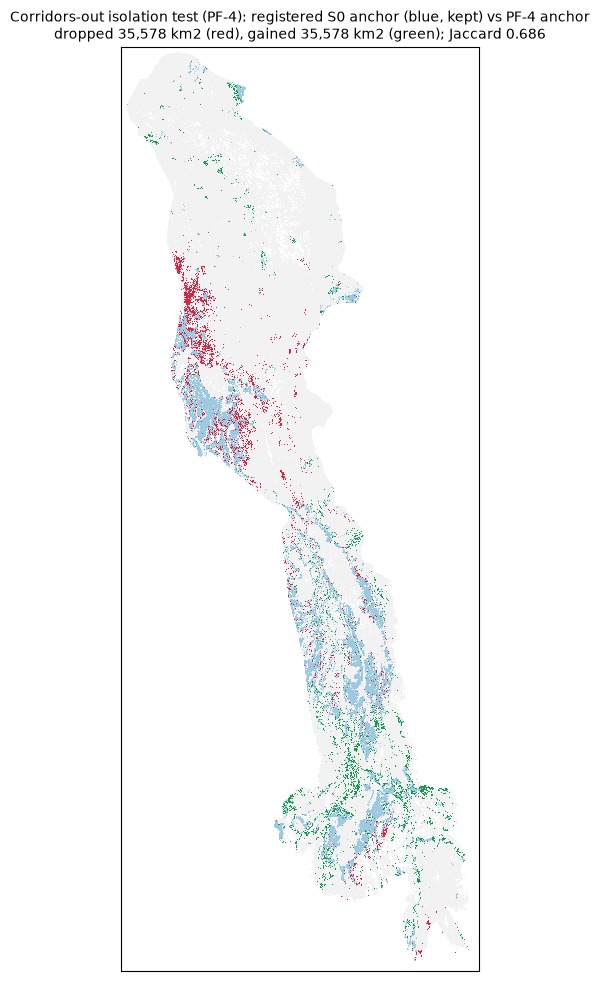

In [5]:
# ---- figure: the swap on the map -----------------------------------------------------------------------------------------------
cls = np.zeros(G.n_pu, np.float32); cls[a_reg & D] = 1; cls[dropped] = 2; cls[gained] = 3
img = dc.to_grid(G, cls); img[~G.pu] = np.nan
from matplotlib.colors import ListedColormap
fig, ax = plt.subplots(figsize=(7, 12))
ax.imshow(img, cmap=ListedColormap(["#f2f2f2", "#9ecae1", "#d7263d", "#1a9850"]), vmin=-0.5, vmax=3.5, interpolation="nearest")
ax.set_xticks([]); ax.set_yticks([])
ax.set_title(f"Corridors-out isolation test (PF-4): registered S0 anchor (blue, kept) vs PF-4 anchor\ndropped {int(dropped.sum()):,} km2 (red), gained {int(gained.sum()):,} km2 (green); Jaccard {J:.3f}", fontsize=10)
fig.savefig(FIG / "pf4_corridors_out_swap.png", dpi=150, bbox_inches="tight"); plt.show()
